✅ Device : cpu

  📂  Loading Data
  Train : 5,068 rows
  Val   : 1,086 rows
  Test  : 1,086 rows

  Label distribution (train):
labels
1    2576
0    2492
Name: count, dtype: int64

  🔤  Building Arabic Vocabulary from Training Data
  Vocabulary size : 7,261 tokens
  (from 26,832 unique tokens, min_freq=2)
  Average token length (train): 14.1 words
  Max sequence length set to  : 128

  🏗️  Building Vanilla RNN Model
  Trainable parameters : 2,155,650
  Embedding dim        : 256
  Hidden dim           : 256
  RNN layers           : 2
  Dropout              : 0.4

  Class weights : [1.016853928565979, 0.9836956262588501]

  🚀  Training Vanilla RNN

  EPOCH 1/30
    Epoch 1 | Step   50/80 | Loss 0.7217 | LR 1.00e-03

  ── Epoch 1 Summary ─────────────────────────────────
  Train → Loss: 0.7009 | Acc: 0.5199 | F1: 0.5192
  Val   → Loss: 0.6863 | Acc: 0.5608 | F1: 0.4898
  ✅ New best saved (val F1 = 0.4898)

  EPOCH 2/30
    Epoch 2 | Step   50/80 | Loss 0.6535 | LR 9.97e-04

  ── Epoch 2

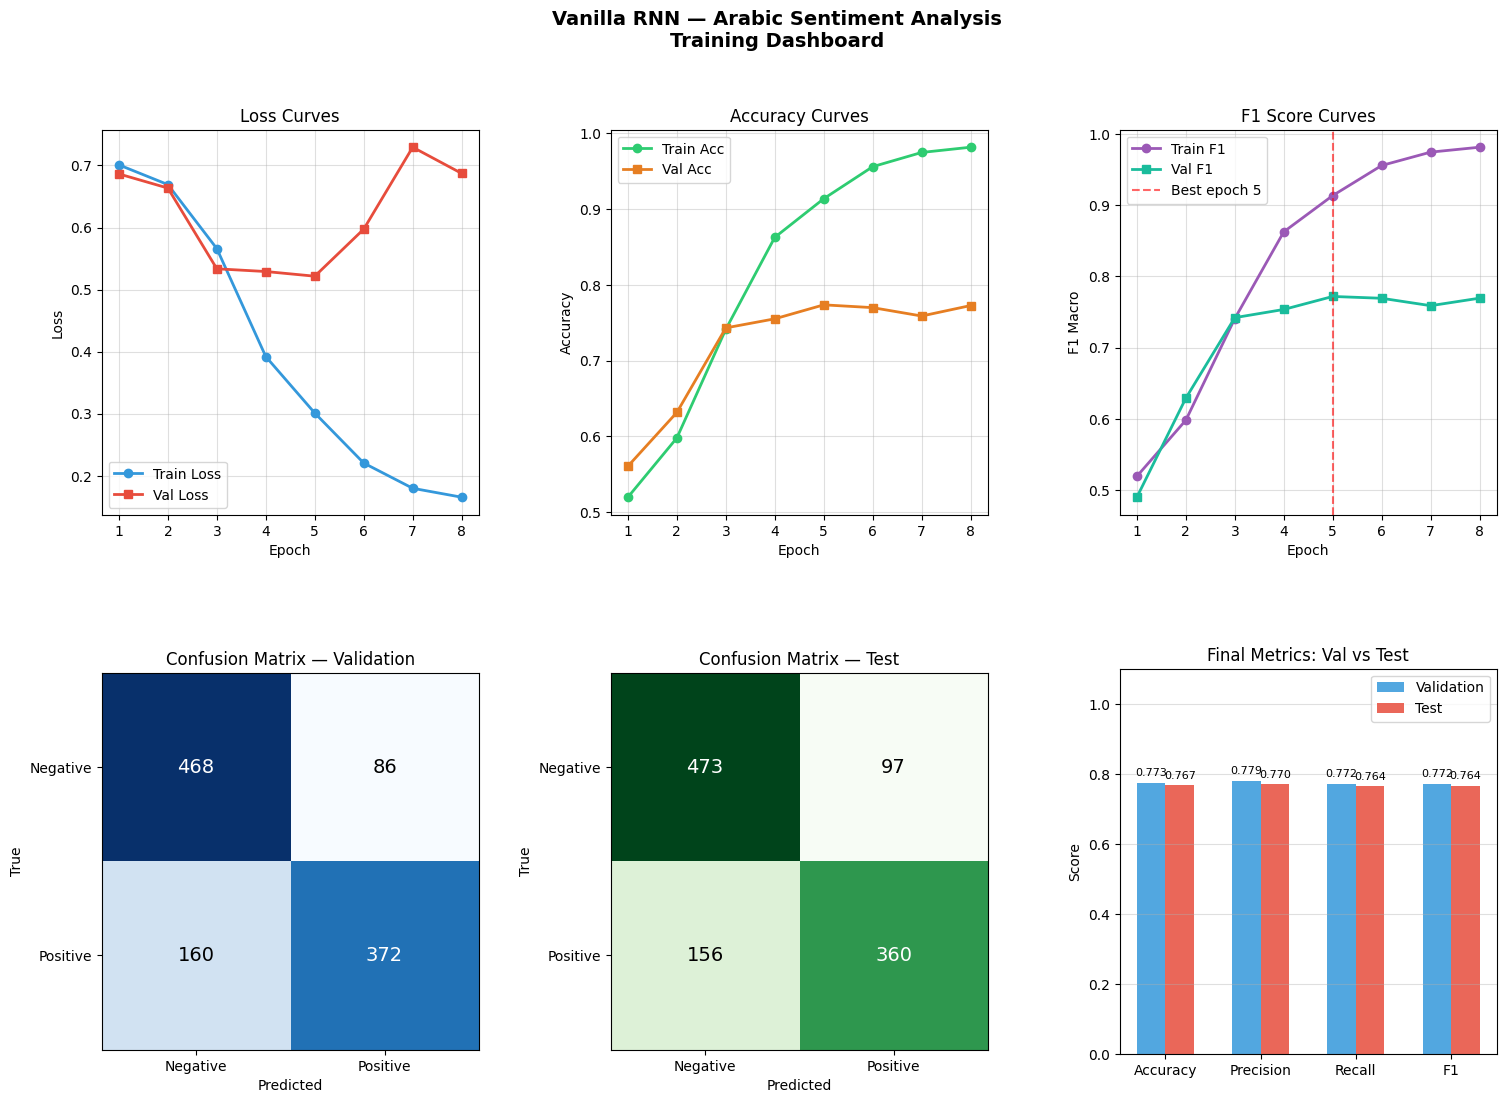

  📊 Plot saved → vanilla_rnn_dashboard.png

  📈  Training History
 epoch  train_loss  train_acc  train_f1  val_loss  val_acc  val_f1
     1      0.7009     0.5199    0.5192    0.6863   0.5608  0.4898
     2      0.6692     0.5981    0.5980    0.6635   0.6317  0.6289
     3      0.5659     0.7413    0.7407    0.5335   0.7431  0.7419
     4      0.3919     0.8625    0.8625    0.5291   0.7551  0.7534
     5      0.3010     0.9134    0.9134    0.5215   0.7735  0.7717
     6      0.2204     0.9556    0.9556    0.5974   0.7698  0.7691
     7      0.1797     0.9743    0.9743    0.7294   0.7587  0.7587
     8      0.1654     0.9813    0.9813    0.6872   0.7726  0.7693

  Best Val F1   : 0.7717
  Model saved   : best_vanilla_rnn.pt


In [1]:
# =============================================================================
# Arabic Sentiment Analysis — Vanilla RNN (From Scratch)
# Architecture : Embedding → Stacked RNN (2 layers) → FC classifier
# Framework    : Pure PyTorch — no HuggingFace, no external NLP libraries
# Tokenizer    : Custom Arabic vocabulary tokenizer built from training data
# Dataset      : train_deep_learning.csv / val_deep_learning.csv / test_deep_learning.csv
#
# WHY VANILLA RNN FOR ARABIC:
#   A vanilla RNN applies the same learned transformation at every time step:
#       h_t = tanh(W_h · h_{t-1} + W_x · x_t + b)
#   It is the simplest sequence model. For Arabic sentiment:
#   • Short tweets / comments: vanilla RNN performs competitively
#   • Its main weakness is vanishing gradients over long sequences
#   • We mitigate this with:
#       - 2 stacked layers (deeper representation without excessive depth)
#       - Gradient clipping (prevents exploding gradients)
#       - Short max sequence length (128 tokens — most comments fit)
#       - tanh activation (bounded, reduces explosion risk vs ReLU)
#   • We use the LAST hidden state as the sentence representation
# =============================================================================

import os
import random
import warnings
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# ─────────────────────────────────────────────────────────────────────────────
# 0. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_PATH   = "/content/train.csv"
VAL_PATH     = "/content/val.csv"
TEST_PATH    = "/content/test.csv"
TEXT_COL     = "clean_text"
LABEL_COL    = "labels"

# Vocabulary
MIN_FREQ     = 2        # ignore tokens that appear fewer than 2 times
MAX_VOCAB    = 30_000   # cap vocabulary size

# Sequence
MAX_SEQ_LEN  = 128      # truncate/pad all sequences to this length

# Model
EMBED_DIM    = 256      # word embedding dimension
HIDDEN_DIM   = 256      # RNN hidden state dimension
NUM_LAYERS   = 2        # stacked RNN layers (2 is safe for vanilla RNN)
DROPOUT      = 0.4      # dropout between RNN layers and before classifier
NUM_CLASSES  = 2

# Training
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 5.0      # clip gradient norm (critical for vanilla RNN)
PATIENCE     = 3       # early stopping patience

# ─────────────────────────────────────────────────────────────────────────────
# 1. CUSTOM ARABIC TOKENIZER (built entirely from training data)
# ─────────────────────────────────────────────────────────────────────────────
class ArabicVocab:
    """
    Simple whitespace-based tokenizer with vocabulary built from training data.

    Arabic text after preprocessing is already space-tokenised (each word
    is a space-separated token). This tokenizer:
      1. Counts token frequencies across the training corpus
      2. Keeps tokens that appear >= MIN_FREQ times (removes noise)
      3. Caps vocabulary at MAX_VOCAB most frequent tokens
      4. Maps tokens ↔ integer indices

    Special tokens:
      [PAD] = 0  — padding to uniform batch length
      [UNK] = 1  — out-of-vocabulary tokens at inference time
    """
    PAD_TOKEN = "[PAD]"
    UNK_TOKEN = "[UNK]"
    PAD_IDX   = 0
    UNK_IDX   = 1

    def __init__(self):
        self.token2idx = {self.PAD_TOKEN: 0, self.UNK_TOKEN: 1}
        self.idx2token = {0: self.PAD_TOKEN, 1: self.UNK_TOKEN}
        self.vocab_size = 2

    def build(self, texts: list, min_freq: int = MIN_FREQ, max_vocab: int = MAX_VOCAB):
        """Build vocabulary from a list of text strings."""
        counter = Counter()
        for text in texts:
            counter.update(str(text).split())

        # Keep tokens above frequency threshold, sorted by frequency
        valid = [(tok, cnt) for tok, cnt in counter.items() if cnt >= min_freq]
        valid.sort(key=lambda x: x[1], reverse=True)
        valid = valid[:max_vocab - 2]   # reserve 2 slots for PAD and UNK

        for tok, _ in valid:
            idx = len(self.token2idx)
            self.token2idx[tok] = idx
            self.idx2token[idx] = tok

        self.vocab_size = len(self.token2idx)
        print(f"  Vocabulary size : {self.vocab_size:,} tokens")
        print(f"  (from {len(counter):,} unique tokens, min_freq={min_freq})")

    def encode(self, text: str, max_len: int = MAX_SEQ_LEN) -> list:
        """
        Tokenise + encode one text string.
        Truncates to max_len and pads from the right.
        Returns: list of integer token ids, length = max_len
        """
        tokens = str(text).split()[:max_len]
        ids    = [self.token2idx.get(t, self.UNK_IDX) for t in tokens]
        # Right-pad with PAD_IDX
        ids   += [self.PAD_IDX] * (max_len - len(ids))
        return ids

    def __len__(self):
        return self.vocab_size


# ─────────────────────────────────────────────────────────────────────────────
# 2. PYTORCH DATASET
# ─────────────────────────────────────────────────────────────────────────────
class ArabicSentimentDataset(Dataset):
    """
    PyTorch Dataset for Arabic sentiment.
    Each sample: (input_ids, attention_mask, label)
    attention_mask: 1 for real tokens, 0 for padding.
    """
    def __init__(self, df: pd.DataFrame, vocab: ArabicVocab, max_len: int = MAX_SEQ_LEN):
        self.texts   = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels  = df[LABEL_COL].astype(int).tolist()
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        ids  = self.vocab.encode(self.texts[idx], self.max_len)
        mask = [1 if i != ArabicVocab.PAD_IDX else 0 for i in ids]
        return {
            "input_ids":      torch.tensor(ids,  dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_loader(df, vocab, shuffle):
    return DataLoader(
        ArabicSentimentDataset(df, vocab),
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle,
        num_workers = 0,
        pin_memory  = DEVICE.type == "cuda",
    )


# ─────────────────────────────────────────────────────────────────────────────
# 3. VANILLA RNN MODEL
# ─────────────────────────────────────────────────────────────────────────────
class VanillaRNNClassifier(nn.Module):
    """
    Stacked Vanilla RNN for Arabic sentiment classification.

    Architecture:
        Input ids (B, T)
        ↓
        Embedding(vocab_size, embed_dim)   — randomly initialised, trainable
        ↓
        Dropout(embed_dropout)             — regularise embedding layer
        ↓
        RNN(embed_dim → hidden_dim, num_layers=2, nonlinearity='tanh')
            Layer 1: h_t = tanh(W1_h·h_{t-1} + W1_x·x_t + b1)
            Layer 2: h_t = tanh(W2_h·h_{t-1} + W2_x·h1_t + b2)
        ↓
        Last hidden state h_T (top layer)  — sentence representation
        ↓
        LayerNorm → Dropout → Linear(hidden_dim, hidden_dim//2) → ReLU
        → Dropout → Linear(hidden_dim//2, num_classes)

    Why last hidden state for Vanilla RNN:
        Vanilla RNN accumulates all previous information into h_T.
        For short Arabic comments, h_T captures sufficient context.
        (For long sequences, attention pooling would be better — see BiGRU.)

    Gradient issues addressed:
        - tanh nonlinearity (bounded: avoids explosion more than ReLU)
        - GRAD_CLIP = 5.0 (hard ceiling on gradient norm)
        - NUM_LAYERS = 2 (not 3 — each extra layer squares vanishing risk)
        - Dropout only between layers, not inside the RNN cell
    """
    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int,
                 num_layers: int, num_classes: int, dropout: float,
                 pad_idx: int):
        super().__init__()

        # Embedding layer — pad vectors stay zero (no gradient)
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        # Initialise embeddings uniformly (Xavier-like for RNNs)
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        with torch.no_grad():
            self.embedding.weight[pad_idx].fill_(0.0)

        self.embed_dropout = nn.Dropout(dropout * 0.5)   # lighter on embeddings

        # Stacked Vanilla RNN
        self.rnn = nn.RNN(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            nonlinearity  = "tanh",          # tanh is standard for vanilla RNN
            batch_first   = True,
            dropout        = dropout if num_layers > 1 else 0.0,
            bidirectional = False,
        )

        # Classification head
        self.layer_norm  = nn.LayerNorm(hidden_dim)
        self.drop        = nn.Dropout(dropout)
        self.classifier  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        # ── Embedding ──────────────────────────────────────────────────────
        emb = self.embedding(input_ids)          # (B, T, E)
        emb = self.embed_dropout(emb)

        # ── Pack padded sequences for efficient RNN ─────────────────────────
        lengths = attention_mask.sum(dim=1).cpu().clamp(min=1)
        packed  = nn.utils.rnn.pack_padded_sequence(
            emb, lengths, batch_first=True, enforce_sorted=False
        )

        # ── Vanilla RNN ────────────────────────────────────────────────────
        _, h_n = self.rnn(packed)
        # h_n shape: (num_layers, B, hidden_dim)
        # Take last layer's hidden state as sentence representation
        sentence = h_n[-1]                       # (B, hidden_dim)

        # ── Classification head ────────────────────────────────────────────
        out = self.layer_norm(sentence)
        out = self.drop(out)
        return self.classifier(out)              # (B, num_classes)


# ─────────────────────────────────────────────────────────────────────────────
# 4. LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📂  Loading Data")
print("=" * 65)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"  Train : {len(train_df):,} rows")
print(f"  Val   : {len(val_df):,} rows")
print(f"  Test  : {len(test_df):,} rows")
print(f"\n  Label distribution (train):\n{train_df[LABEL_COL].value_counts()}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 5. BUILD VOCABULARY (from training data only — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  🔤  Building Arabic Vocabulary from Training Data")
print("=" * 65)

vocab = ArabicVocab()
vocab.build(train_df[TEXT_COL].fillna("").astype(str).tolist())

# Average sequence length
avg_len = train_df[TEXT_COL].fillna("").astype(str).apply(lambda x: len(x.split())).mean()
print(f"  Average token length (train): {avg_len:.1f} words")
print(f"  Max sequence length set to  : {MAX_SEQ_LEN}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 6. CREATE DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────
train_loader = make_loader(train_df, vocab, shuffle=True)
val_loader   = make_loader(val_df,   vocab, shuffle=False)
test_loader  = make_loader(test_df,  vocab, shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 7. MODEL + OPTIMIZER + LOSS
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  🏗️  Building Vanilla RNN Model")
print("=" * 65)

model = VanillaRNNClassifier(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
    pad_idx     = ArabicVocab.PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters : {total_params:,}")
print(f"  Embedding dim        : {EMBED_DIM}")
print(f"  Hidden dim           : {HIDDEN_DIM}")
print(f"  RNN layers           : {NUM_LAYERS}")
print(f"  Dropout              : {DROPOUT}\n")

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing: warms up and smoothly decays LR — better than step decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

# Class-balanced loss weights
label_counts = train_df[LABEL_COL].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_CLASSES * c) for c in label_counts.values],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

print(f"  Class weights : {class_weights.cpu().tolist()}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. TRAINING AND EVALUATION FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(epoch: int):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for step, batch in enumerate(train_loader):
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        y     = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, y)
        loss.backward()

        # Gradient clipping — essential for vanilla RNN
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        if (step + 1) % 50 == 0:
            print(f"    Epoch {epoch+1} | Step {step+1:4d}/{len(train_loader)} "
                  f"| Loss {loss.item():.4f} | LR {scheduler.get_last_lr()[0]:.2e}")

    return (
        total_loss / len(train_loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro", zero_division=0),
    )


@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        y     = batch["label"].to(DEVICE)

        logits      = model(ids, mask)
        total_loss += criterion(logits, y).item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


def print_metrics(title: str, y_true, y_pred):
    label_names = ["Negative", "Positive"]
    print(f"\n{'─'*65}\n  {title}\n{'─'*65}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    print(f"  Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")


# ─────────────────────────────────────────────────────────────────────────────
# 9. TRAINING LOOP WITH EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  🚀  Training Vanilla RNN")
print("=" * 65)

best_val_f1      = 0.0
best_model_state = None
patience_counter = 0
history          = []

for epoch in range(EPOCHS):
    print(f"\n{'='*65}\n  EPOCH {epoch+1}/{EPOCHS}\n{'='*65}")

    tr_loss, tr_acc, tr_f1 = train_one_epoch(epoch)
    vl_loss, vl_preds, vl_labels = evaluate_loader(val_loader)
    vl_acc = accuracy_score(vl_labels, vl_preds)
    vl_f1  = f1_score(vl_labels, vl_preds, average="macro", zero_division=0)

    scheduler.step()

    history.append({
        "epoch":      epoch + 1,
        "train_loss": tr_loss,
        "train_acc":  tr_acc,
        "train_f1":   tr_f1,
        "val_loss":   vl_loss,
        "val_acc":    vl_acc,
        "val_f1":     vl_f1,
    })

    print(f"\n  ── Epoch {epoch+1} Summary ─────────────────────────────────")
    print(f"  Train → Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | F1: {tr_f1:.4f}")
    print(f"  Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f} | F1: {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1      = vl_f1
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        torch.save(best_model_state, "best_vanilla_rnn.pt")
        print(f"  ✅ New best saved (val F1 = {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch+1}.")
            break

# ─────────────────────────────────────────────────────────────────────────────
# 10. FINAL EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📊  Final Evaluation (best checkpoint)")
print("=" * 65)

model.load_state_dict(best_model_state)
model.eval()

_, val_preds, val_labels   = evaluate_loader(val_loader)
_, test_preds, test_labels = evaluate_loader(test_loader)

print_metrics("Validation Set", val_labels, val_preds)
print_metrics("Test Set",       test_labels, test_preds)

# ─────────────────────────────────────────────────────────────────────────────
# 11. VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
hist_df = pd.DataFrame(history)

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Vanilla RNN — Arabic Sentiment Analysis\nTraining Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Loss curves ───────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train Loss",
         color="#3498db", linewidth=2)
ax1.plot(hist_df["epoch"], hist_df["val_loss"],   "s-", label="Val Loss",
         color="#e74c3c", linewidth=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(alpha=0.4)

# ── Accuracy curves ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(hist_df["epoch"], hist_df["train_acc"], "o-", label="Train Acc",
         color="#2ecc71", linewidth=2)
ax2.plot(hist_df["epoch"], hist_df["val_acc"],   "s-", label="Val Acc",
         color="#e67e22", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves"); ax2.legend(); ax2.grid(alpha=0.4)

# ── F1 curves ─────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(hist_df["epoch"], hist_df["train_f1"], "o-", label="Train F1",
         color="#9b59b6", linewidth=2)
ax3.plot(hist_df["epoch"], hist_df["val_f1"],   "s-", label="Val F1",
         color="#1abc9c", linewidth=2)
best_ep = hist_df["val_f1"].idxmax()
ax3.axvline(hist_df["epoch"][best_ep], color="red", linestyle="--",
            alpha=0.6, label=f"Best epoch {hist_df['epoch'][best_ep]}")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1 Macro")
ax3.set_title("F1 Score Curves"); ax3.legend(); ax3.grid(alpha=0.4)

# ── Confusion Matrix — Validation ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
cm_val = confusion_matrix(val_labels, val_preds)
im = ax4.imshow(cm_val, cmap="Blues")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["Negative","Positive"]); ax4.set_yticklabels(["Negative","Positive"])
ax4.set_xlabel("Predicted"); ax4.set_ylabel("True")
ax4.set_title("Confusion Matrix — Validation")
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(cm_val[i,j]), ha="center", va="center",
                 fontsize=14, color="white" if cm_val[i,j] > cm_val.max()/2 else "black")

# ── Confusion Matrix — Test ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cm_test = confusion_matrix(test_labels, test_preds)
ax5.imshow(cm_test, cmap="Greens")
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(["Negative","Positive"]); ax5.set_yticklabels(["Negative","Positive"])
ax5.set_xlabel("Predicted"); ax5.set_ylabel("True")
ax5.set_title("Confusion Matrix — Test")
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm_test[i,j]), ha="center", va="center",
                 fontsize=14, color="white" if cm_test[i,j] > cm_test.max()/2 else "black")

# ── Final Metric Bar Chart ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
metrics_val  = [accuracy_score(val_labels,  val_preds),
                precision_score(val_labels,  val_preds, average="macro", zero_division=0),
                recall_score(val_labels,     val_preds, average="macro", zero_division=0),
                f1_score(val_labels,         val_preds, average="macro", zero_division=0)]
metrics_test = [accuracy_score(test_labels, test_preds),
                precision_score(test_labels, test_preds, average="macro", zero_division=0),
                recall_score(test_labels,    test_preds, average="macro", zero_division=0),
                f1_score(test_labels,        test_preds, average="macro", zero_division=0)]
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(4); w = 0.3
ax6.bar(x - w/2, metrics_val,  w, label="Validation", color="#3498db", alpha=0.85)
ax6.bar(x + w/2, metrics_test, w, label="Test",       color="#e74c3c", alpha=0.85)
ax6.set_xticks(x); ax6.set_xticklabels(metric_names)
ax6.set_ylim(0, 1.1); ax6.set_ylabel("Score")
ax6.set_title("Final Metrics: Val vs Test")
ax6.legend(); ax6.grid(axis="y", alpha=0.4)
for i, (v, t) in enumerate(zip(metrics_val, metrics_test)):
    ax6.text(i-w/2, v+0.02, f"{v:.3f}", ha="center", fontsize=8)
    ax6.text(i+w/2, t+0.02, f"{t:.3f}", ha="center", fontsize=8)

plt.savefig("vanilla_rnn_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Plot saved → vanilla_rnn_dashboard.png")

# ─────────────────────────────────────────────────────────────────────────────
# 12. TRAINING HISTORY SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📈  Training History")
print("=" * 65)
print(hist_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\n  Best Val F1   : {best_val_f1:.4f}")
print(f"  Model saved   : best_vanilla_rnn.pt")

✅ Device : cpu

  📂  Loading Data
  Train : 5,068 | Val : 1,086 | Test : 1,086

  Label distribution (train):
labels
1    2576
0    2492
Name: count, dtype: int64

  🔤  Building Arabic Vocabulary
  Vocabulary size : 7,261 (from 26,832 unique, min_freq=2)

  🏗️  Building BiGRU Model
  Trainable parameters   : 4,490,243
  Embedding dim          : 256
  Hidden dim per dir     : 256  (total: 512)
  BiGRU layers           : 2 bidirectional
  Attention heads        : 8 × 64d
  Dropout                : 0.4

  Class weights : [1.016853928565979, 0.9836956262588501]

  🚀  Training BiGRU

  EPOCH 1/30
    Epoch 1 | Step   50/80 | Loss 0.6937 | LR 5.25e-05

  Train → Loss: 0.7095 | Acc: 0.5253 | F1: 0.5253
  Val   → Loss: 0.6850 | Acc: 0.5147 | F1: 0.3481
  Blend β (attn weight): 0.622
  ✅ Best saved (val F1 = 0.3481)

  EPOCH 2/30
    Epoch 2 | Step   50/80 | Loss 0.6943 | LR 1.63e-04

  Train → Loss: 0.6840 | Acc: 0.5578 | F1: 0.5577
  Val   → Loss: 0.6581 | Acc: 0.6326 | F1: 0.6129
  Blend β (

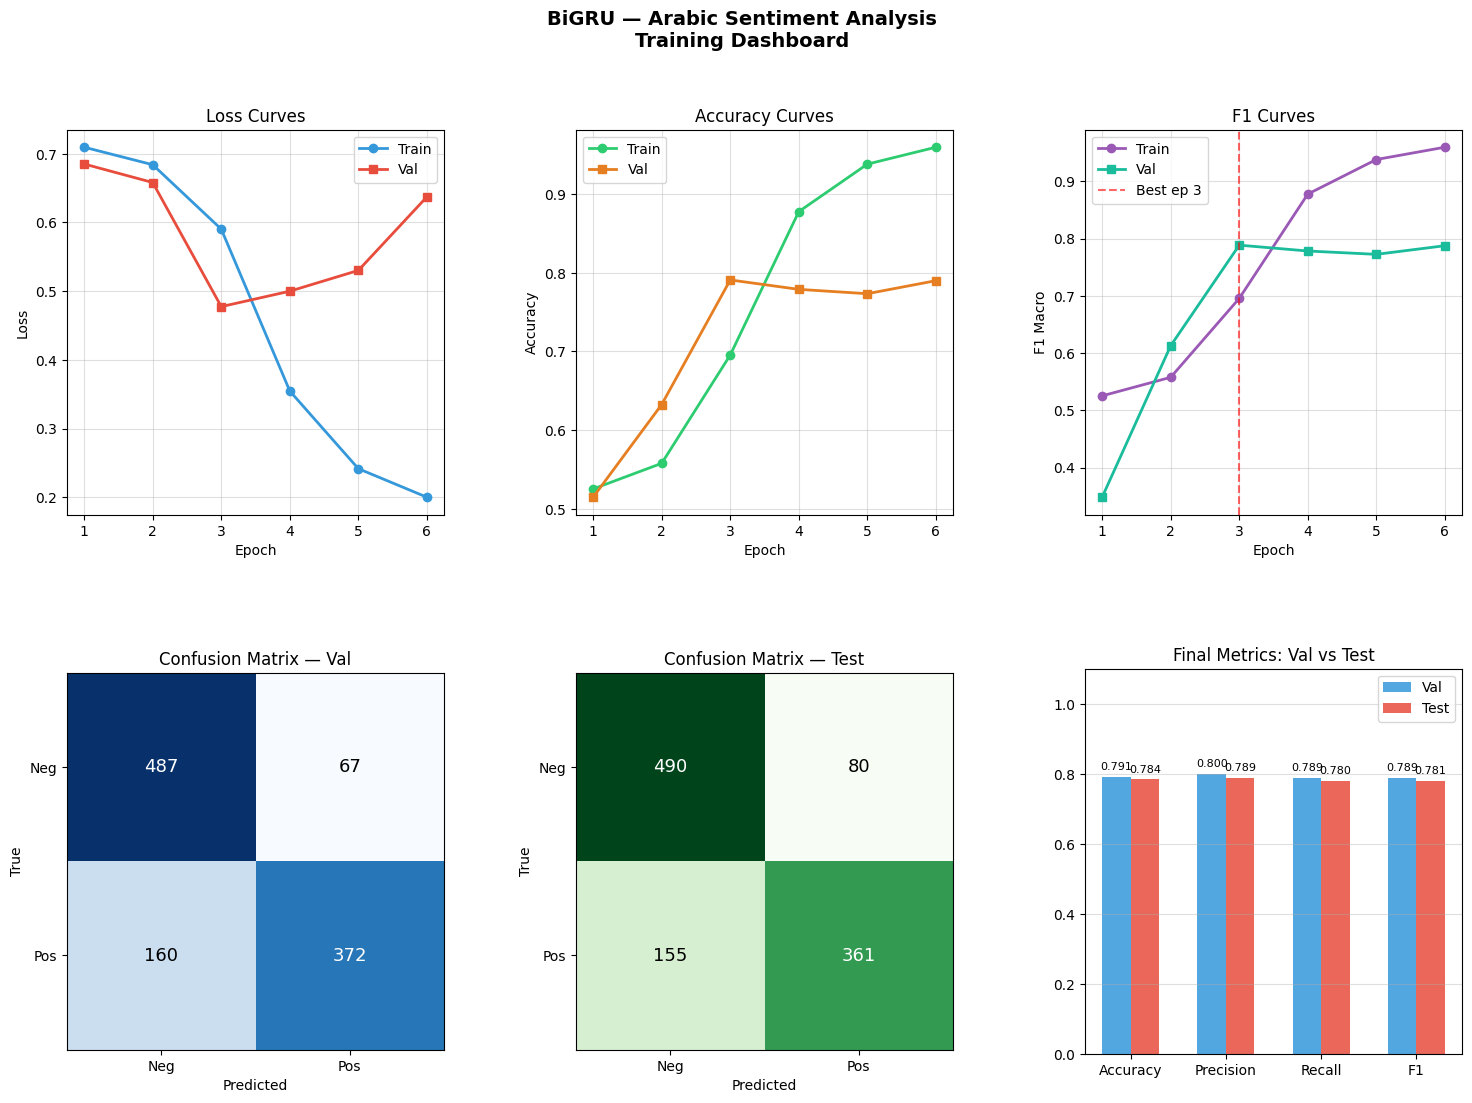

  📊 Plot saved → bigru_dashboard.png

  📈  Training History
 epoch  train_loss  train_acc  train_f1  val_loss  val_acc  val_f1
     1      0.7095     0.5253    0.5253    0.6850   0.5147  0.3481
     2      0.6840     0.5578    0.5577    0.6581   0.6326  0.6129
     3      0.5902     0.6955    0.6955    0.4775   0.7910  0.7886
     4      0.3547     0.8779    0.8779    0.4999   0.7790  0.7784
     5      0.2417     0.9382    0.9382    0.5302   0.7735  0.7725
     6      0.2002     0.9597    0.9597    0.6373   0.7901  0.7876

  Best Val F1 : 0.7886 | Model saved: best_bigru.pt


In [2]:
# =============================================================================
# Arabic Sentiment Analysis — BiGRU (Bidirectional GRU, From Scratch)
# Architecture : Embedding → Stacked BiGRU (2 layers) → Multi-Head Attention
#                → Residual Max-Pool → FC classifier
# Framework    : Pure PyTorch — no HuggingFace, no external NLP libraries
# Tokenizer    : Custom Arabic vocabulary tokenizer built from training data
# Dataset      : train_deep_learning.csv / val_deep_learning.csv / test_deep_learning.csv
#
# WHY BiGRU FOR ARABIC SENTIMENT:
#
#   GRU (Gated Recurrent Unit) improves on vanilla RNN with two gates:
#     • Reset gate  r_t = σ(W_r·[h_{t-1}, x_t])  — how much past to forget
#     • Update gate z_t = σ(W_z·[h_{t-1}, x_t])  — balance old vs new
#     • h_t = (1−z_t)·h_{t-1} + z_t·tanh(W·[r_t⊙h_{t-1}, x_t])
#   GRU uses FEWER parameters than LSTM (no cell state) while achieving
#   comparable performance — faster to train.
#
#   Bidirectional = reads each Arabic comment in BOTH directions:
#     • Forward:  reads right-to-left (Arabic natural direction)
#     • Backward: reads left-to-right
#   Arabic VSO (Verb-Subject-Object) word order means a sentiment word
#   may have critical context AFTER it — the backward pass captures this.
#
#   Multi-Head Attention Pooling over ALL BiGRU hidden states:
#     • The last hidden state alone may miss key sentiment tokens
#     • 8 attention heads simultaneously focus on different aspects:
#       sentiment adjective, negation particle, intensifier, subject
#     • Context = weighted sum Σ α_t^h · h_t over all positions
#
#   Residual max-pool branch (blended with attention context):
#     • Max-pool selects the single strongest activation per dimension
#     • Captures the most extreme sentiment signal in the comment
#     • Blended with attention via a learned scalar gate β
# =============================================================================

import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# ─────────────────────────────────────────────────────────────────────────────
# 0. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_PATH   = "/content/train.csv"
VAL_PATH     = "/content/val.csv"
TEST_PATH    = "/content/test.csv"
TEXT_COL      = "clean_text"
LABEL_COL     = "labels"

MIN_FREQ      = 2
MAX_VOCAB     = 30_000
MAX_SEQ_LEN   = 128

EMBED_DIM     = 256
HIDDEN_DIM    = 256      # per direction; total = 512
NUM_LAYERS    = 2        # 2 bidirectional layers
ATT_HEADS     = 8        # multi-head attention heads over BiGRU outputs
ATT_HEAD_DIM  = 64       # dimension per head
DROPOUT       = 0.4
NUM_CLASSES   = 2

BATCH_SIZE    = 64
EPOCHS        = 30
LR            = 8e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 5.0
PATIENCE      = 3

# ─────────────────────────────────────────────────────────────────────────────
# 1. CUSTOM ARABIC VOCABULARY TOKENIZER
# ─────────────────────────────────────────────────────────────────────────────
class ArabicVocab:
    PAD_TOKEN = "[PAD]"; UNK_TOKEN = "[UNK]"
    PAD_IDX   = 0;       UNK_IDX   = 1

    def __init__(self):
        self.token2idx = {self.PAD_TOKEN: 0, self.UNK_TOKEN: 1}
        self.idx2token = {0: self.PAD_TOKEN, 1: self.UNK_TOKEN}

    def build(self, texts, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB):
        counter = Counter()
        for t in texts: counter.update(str(t).split())
        valid = sorted([(tok,cnt) for tok,cnt in counter.items() if cnt >= min_freq],
                       key=lambda x: x[1], reverse=True)[:max_vocab-2]
        for tok,_ in valid:
            idx = len(self.token2idx)
            self.token2idx[tok] = idx; self.idx2token[idx] = tok
        print(f"  Vocabulary size : {len(self.token2idx):,} "
              f"(from {len(counter):,} unique, min_freq={min_freq})")

    def encode(self, text, max_len=MAX_SEQ_LEN):
        tokens = str(text).split()[:max_len]
        ids    = [self.token2idx.get(t, self.UNK_IDX) for t in tokens]
        ids   += [self.PAD_IDX] * (max_len - len(ids))
        return ids

    def __len__(self): return len(self.token2idx)


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATASET
# ─────────────────────────────────────────────────────────────────────────────
class ArabicSentimentDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_SEQ_LEN):
        self.texts  = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[LABEL_COL].astype(int).tolist()
        self.vocab  = vocab; self.max_len = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        ids  = self.vocab.encode(self.texts[idx], self.max_len)
        mask = [1 if i != ArabicVocab.PAD_IDX else 0 for i in ids]
        return {
            "input_ids":      torch.tensor(ids,  dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_loader(df, vocab, shuffle):
    return DataLoader(ArabicSentimentDataset(df, vocab), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0, pin_memory=DEVICE.type=="cuda")


# ─────────────────────────────────────────────────────────────────────────────
# 3. MULTI-HEAD ATTENTION POOLING MODULE
# ─────────────────────────────────────────────────────────────────────────────
class MultiHeadAttentionPooling(nn.Module):
    """
    Multi-head attention pooling over a sequence of BiGRU hidden states.

    Each head h learns its own attention distribution:
        proj^h  = tanh(W^h · hidden)       (B, T, head_dim)
        score^h = v^h · proj^h             (B, T)
        α^h     = softmax(score^h)         normalised over T (masked)
        ctx^h   = Σ_t α^h_t · proj^h_t    (B, head_dim)

    All heads concatenated → projected to input_dim.
    This lets the model simultaneously attend to:
        head 1 → sentiment adjective position
        head 2 → negation particle
        head 3 → subject / topic
        ...etc.
    """
    def __init__(self, input_dim: int, num_heads: int, head_dim: int):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = head_dim

        # Per-head projection: maps each hidden state → head_dim
        self.W   = nn.Linear(input_dim, num_heads * head_dim)
        # Per-head attention scoring vector
        self.v   = nn.Parameter(torch.randn(num_heads, head_dim) * 0.01)
        # Output projection: (num_heads * head_dim) → input_dim
        self.out = nn.Linear(num_heads * head_dim, input_dim)
        self.drop = nn.Dropout(DROPOUT * 0.5)

    def forward(self, hidden: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        hidden : (B, T, D)
        mask   : (B, T)  1=real, 0=pad
        Returns: (B, D)
        """
        B, T, D = hidden.shape
        proj  = torch.tanh(self.W(hidden))               # (B, T, H*d)
        proj  = proj.view(B, T, self.num_heads, self.head_dim)  # (B,T,H,d)

        # Score: dot with head vector v → (B, T, H)
        scores = torch.einsum("bthd,hd->bth", proj, self.v)
        scores = scores.permute(0, 2, 1)                 # (B, H, T)

        # Mask padding
        mask_exp = mask.unsqueeze(1).expand_as(scores)
        scores   = scores.masked_fill(mask_exp == 0, -1e9)
        alpha    = F.softmax(scores, dim=-1)             # (B, H, T)
        alpha    = self.drop(alpha)

        # Weighted context per head: (B, H, d)
        proj_p   = proj.permute(0, 2, 1, 3)             # (B, H, T, d)
        ctx      = torch.einsum("bht,bhtd->bhd", alpha, proj_p)
        ctx_flat = ctx.reshape(B, self.num_heads * self.head_dim)

        return self.out(ctx_flat)                        # (B, D)


# ─────────────────────────────────────────────────────────────────────────────
# 4. BiGRU MODEL
# ─────────────────────────────────────────────────────────────────────────────
class BiGRUClassifier(nn.Module):
    """
    Stacked Bidirectional GRU with Multi-Head Attention + Residual Max-Pool.

    Full pipeline:
        Input ids (B, T)
        ↓
        Embedding(vocab_size, embed_dim)         randomly initialised, trainable
        ↓  Dropout
        ↓
        Pack padded sequence
        ↓
        GRU(embed_dim, hidden_dim, layers=2, bidirectional=True)
            → output: (B, T, 2*hidden_dim)  hidden states for each position
            → h_n:    (2*layers, B, hidden_dim)  final states
        ↓
        LayerNorm
        ↓
        ┌─── Multi-Head Attention pooling ────────────────────┐
        │    8 heads × 64 dim → (B, 2*hidden_dim)            │
        └────────────────────────────────────────────────────┘
              ⊕ (learnable blend β)
        ┌─── Residual Max-Pool ───────────────────────────────┐
        │    masked max over T → (B, 2*hidden_dim)           │
        └────────────────────────────────────────────────────┘
        ↓
        Dropout → Linear(2H → H) → GELU → Dropout → Linear(H → 2)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers,
                 att_heads, att_head_dim, num_classes, dropout, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[pad_idx].fill_(0.0)

        self.embed_drop = nn.Dropout(dropout * 0.6)

        # Stacked BiGRU
        self.bigru = nn.GRU(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            bidirectional = True,
            batch_first   = True,
            dropout        = dropout if num_layers > 1 else 0.0,
        )

        bilstm_out_dim = hidden_dim * 2   # bidirectional

        # LayerNorm after BiGRU
        self.lstm_norm = nn.LayerNorm(bilstm_out_dim)

        # Multi-head attention pooling
        self.attention = MultiHeadAttentionPooling(
            input_dim = bilstm_out_dim,
            num_heads = att_heads,
            head_dim  = att_head_dim,
        )

        # Learnable blend between attention context and max-pool
        self.blend = nn.Parameter(torch.tensor(0.5))

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(bilstm_out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        # ── Embedding ──────────────────────────────────────────────────────
        emb = self.embed_drop(self.embedding(input_ids))   # (B, T, E)

        # ── Pack + BiGRU ───────────────────────────────────────────────────
        lengths = attention_mask.sum(1).cpu().clamp(min=1)
        packed  = nn.utils.rnn.pack_padded_sequence(
            emb, lengths, batch_first=True, enforce_sorted=False)
        gru_out, _ = self.bigru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(
            gru_out, batch_first=True, total_length=emb.size(1))   # (B,T,2H)

        gru_out = self.lstm_norm(gru_out)

        # ── Multi-Head Attention pooling ───────────────────────────────────
        attn_ctx = self.attention(gru_out, attention_mask)   # (B, 2H)

        # ── Residual max-pool (masked) ─────────────────────────────────────
        mask_exp  = attention_mask.unsqueeze(-1).float()
        masked    = gru_out * mask_exp + (1 - mask_exp) * (-1e9)
        max_pool  = masked.max(dim=1).values                 # (B, 2H)

        # ── Blend attention + max-pool ─────────────────────────────────────
        β     = torch.sigmoid(self.blend)
        mixed = β * attn_ctx + (1.0 - β) * max_pool         # (B, 2H)

        return self.classifier(mixed)                        # (B, num_classes)


# ─────────────────────────────────────────────────────────────────────────────
# 5. LOAD DATA + BUILD VOCAB
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📂  Loading Data")
print("=" * 65)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
print(f"\n  Label distribution (train):\n{train_df[LABEL_COL].value_counts()}\n")

print("=" * 65)
print("  🔤  Building Arabic Vocabulary")
print("=" * 65)

vocab = ArabicVocab()
vocab.build(train_df[TEXT_COL].fillna("").astype(str).tolist())

train_loader = make_loader(train_df, vocab, shuffle=True)
val_loader   = make_loader(val_df,   vocab, shuffle=False)
test_loader  = make_loader(test_df,  vocab, shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 6. MODEL + OPTIMIZER + SCHEDULER + LOSS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  🏗️  Building BiGRU Model")
print("=" * 65)

model = BiGRUClassifier(
    vocab_size   = len(vocab),
    embed_dim    = EMBED_DIM,
    hidden_dim   = HIDDEN_DIM,
    num_layers   = NUM_LAYERS,
    att_heads    = ATT_HEADS,
    att_head_dim = ATT_HEAD_DIM,
    num_classes  = NUM_CLASSES,
    dropout      = DROPOUT,
    pad_idx      = ArabicVocab.PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters   : {total_params:,}")
print(f"  Embedding dim          : {EMBED_DIM}")
print(f"  Hidden dim per dir     : {HIDDEN_DIM}  (total: {HIDDEN_DIM*2})")
print(f"  BiGRU layers           : {NUM_LAYERS} bidirectional")
print(f"  Attention heads        : {ATT_HEADS} × {ATT_HEAD_DIM}d")
print(f"  Dropout                : {DROPOUT}\n")

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# OneCycleLR: ramps LR up then down — very effective for GRU
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader), epochs=EPOCHS,
    pct_start=0.2, anneal_strategy="cos",
)

label_counts  = train_df[LABEL_COL].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_CLASSES * c) for c in label_counts.values],
    dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
print(f"  Class weights : {class_weights.cpu().tolist()}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. TRAINING HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(epoch):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for step, batch in enumerate(train_loader):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y    = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        if (step+1) % 50 == 0:
            print(f"    Epoch {epoch+1} | Step {step+1:4d}/{len(train_loader)} "
                  f"| Loss {loss.item():.4f} | LR {scheduler.get_last_lr()[0]:.2e}")
    return (total_loss/len(train_loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro", zero_division=0))


@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y    = batch["label"].to(DEVICE)
        logits = model(ids, mask)
        total_loss += criterion(logits, y).item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss/len(loader), np.array(all_preds), np.array(all_labels)


def print_metrics(title, y_true, y_pred):
    names = ["Negative", "Positive"]
    print(f"\n{'─'*65}\n  {title}\n{'─'*65}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=names, zero_division=0))
    print(f"  Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")


# ─────────────────────────────────────────────────────────────────────────────
# 8. TRAINING LOOP WITH EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  🚀  Training BiGRU")
print("=" * 65)

best_val_f1, best_state, patience_counter, history = 0.0, None, 0, []

for epoch in range(EPOCHS):
    print(f"\n{'='*65}\n  EPOCH {epoch+1}/{EPOCHS}\n{'='*65}")
    tr_loss, tr_acc, tr_f1 = train_one_epoch(epoch)
    vl_loss, vl_preds, vl_labels = evaluate_loader(val_loader)
    vl_acc = accuracy_score(vl_labels, vl_preds)
    vl_f1  = f1_score(vl_labels, vl_preds, average="macro", zero_division=0)

    history.append({"epoch": epoch+1, "train_loss": tr_loss, "train_acc": tr_acc,
                    "train_f1": tr_f1, "val_loss": vl_loss, "val_acc": vl_acc, "val_f1": vl_f1})

    print(f"\n  Train → Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | F1: {tr_f1:.4f}")
    print(f"  Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f} | F1: {vl_f1:.4f}")
    print(f"  Blend β (attn weight): {torch.sigmoid(model.blend).item():.3f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1; patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "best_bigru.pt")
        print(f"  ✅ Best saved (val F1 = {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch+1}."); break

# ─────────────────────────────────────────────────────────────────────────────
# 9. FINAL EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
model.load_state_dict(best_state); model.eval()
_, val_preds, val_labels   = evaluate_loader(val_loader)
_, test_preds, test_labels = evaluate_loader(test_loader)
print_metrics("Validation Set", val_labels, val_preds)
print_metrics("Test Set",       test_labels, test_preds)

# ─────────────────────────────────────────────────────────────────────────────
# 10. VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
hist_df = pd.DataFrame(history)
fig = plt.figure(figsize=(18, 12))
fig.suptitle("BiGRU — Arabic Sentiment Analysis\nTraining Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train", color="#3498db", linewidth=2)
ax1.plot(hist_df["epoch"], hist_df["val_loss"],   "s-", label="Val",   color="#e74c3c", linewidth=2)
ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(alpha=0.4)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(hist_df["epoch"], hist_df["train_acc"], "o-", label="Train", color="#2ecc71", linewidth=2)
ax2.plot(hist_df["epoch"], hist_df["val_acc"],   "s-", label="Val",   color="#e67e22", linewidth=2)
ax2.set_title("Accuracy Curves"); ax2.legend(); ax2.grid(alpha=0.4)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")

ax3 = fig.add_subplot(gs[0,2])
ax3.plot(hist_df["epoch"], hist_df["train_f1"], "o-", label="Train", color="#9b59b6", linewidth=2)
ax3.plot(hist_df["epoch"], hist_df["val_f1"],   "s-", label="Val",   color="#1abc9c", linewidth=2)
best_ep = hist_df["val_f1"].idxmax()
ax3.axvline(hist_df["epoch"][best_ep], color="red", linestyle="--", alpha=0.6,
            label=f"Best ep {hist_df['epoch'][best_ep]}")
ax3.set_title("F1 Curves"); ax3.legend(); ax3.grid(alpha=0.4)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1 Macro")

for ax, cm, title, cmap in [
    (fig.add_subplot(gs[1,0]), confusion_matrix(val_labels, val_preds),  "Confusion Matrix — Val",  "Blues"),
    (fig.add_subplot(gs[1,1]), confusion_matrix(test_labels, test_preds),"Confusion Matrix — Test", "Greens"),
]:
    ax.imshow(cm, cmap=cmap); ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg","Pos"]); ax.set_yticklabels(["Neg","Pos"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=13,
                    color="white" if cm[i,j]>cm.max()/2 else "black")

ax6 = fig.add_subplot(gs[1,2])
mv = [accuracy_score(val_labels,val_preds), precision_score(val_labels,val_preds,average="macro",zero_division=0),
      recall_score(val_labels,val_preds,average="macro",zero_division=0), f1_score(val_labels,val_preds,average="macro",zero_division=0)]
mt = [accuracy_score(test_labels,test_preds), precision_score(test_labels,test_preds,average="macro",zero_division=0),
      recall_score(test_labels,test_preds,average="macro",zero_division=0), f1_score(test_labels,test_preds,average="macro",zero_division=0)]
x=np.arange(4); w=0.3
ax6.bar(x-w/2,mv,w,label="Val", color="#3498db",alpha=0.85)
ax6.bar(x+w/2,mt,w,label="Test",color="#e74c3c",alpha=0.85)
ax6.set_xticks(x); ax6.set_xticklabels(["Accuracy","Precision","Recall","F1"])
ax6.set_ylim(0,1.1); ax6.legend(); ax6.grid(axis="y",alpha=0.4)
ax6.set_title("Final Metrics: Val vs Test")
for i,(v,t) in enumerate(zip(mv,mt)):
    ax6.text(i-w/2,v+0.02,f"{v:.3f}",ha="center",fontsize=8)
    ax6.text(i+w/2,t+0.02,f"{t:.3f}",ha="center",fontsize=8)

plt.savefig("bigru_dashboard.png", dpi=150, bbox_inches="tight"); plt.show()
print("  📊 Plot saved → bigru_dashboard.png")

print("\n" + "="*65 + "\n  📈  Training History\n" + "="*65)
print(hist_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\n  Best Val F1 : {best_val_f1:.4f} | Model saved: best_bigru.pt")

✅ Device : cpu

  📂  Loading Data
  Train : 5,068 | Val : 1,086 | Test : 1,086

  Label distribution (train):
labels
1    2576
0    2492
Name: count, dtype: int64

  🔤  Building Arabic Vocabulary
  Vocabulary size : 7,261 (from 26,832 unique, min_freq=2)
  Average token length : 14.1 | Max seq len: 128

  🏗️  Building LSTM Model
  Trainable parameters   : 3,866,242
  Embedding dim          : 256
  LSTM hidden dim        : 256
  LSTM layers            : 3 (unidirectional)
  Pooling                : Bahdanau Attention + Max-Pool + Last State
  Dropout                : 0.4

  Class weights : [1.016853928565979, 0.9836956262588501]

  🚀  Training LSTM

  EPOCH 1/30
    Epoch 1 | Step   50/80 | Loss 0.6799 | LR 7.93e-04

  Train → Loss: 0.7014 | Acc: 0.5020 | F1: 0.5015
  Val   → Loss: 0.6916 | Acc: 0.5101 | F1: 0.3378
  ✅ Best saved (val F1 = 0.3378)

  EPOCH 2/30
    Epoch 2 | Step   50/80 | Loss 0.6909 | LR 7.50e-04

  Train → Loss: 0.6790 | Acc: 0.5450 | F1: 0.5443
  Val   → Loss: 0.603

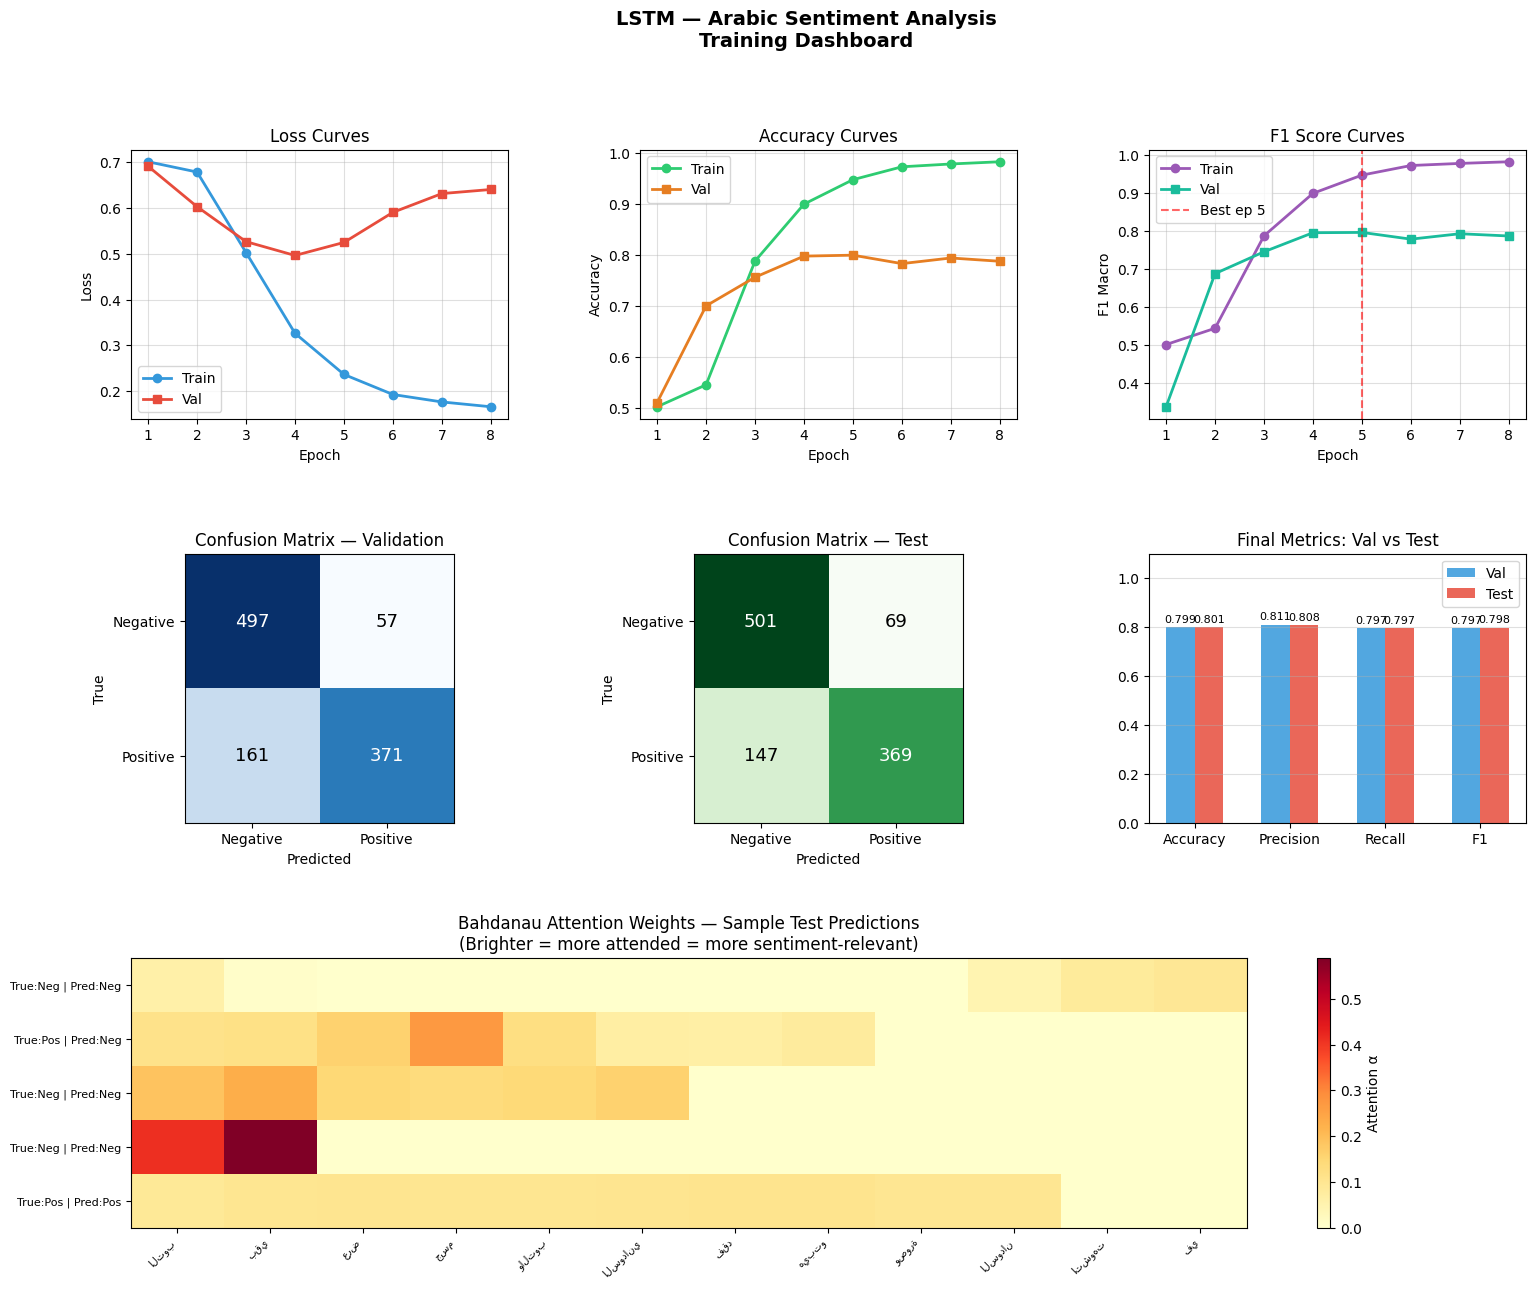

  📊 Plot saved → lstm_dashboard.png

  📈  Training History
 epoch  train_loss  train_acc  train_f1  val_loss  val_acc  val_f1
     1      0.7014     0.5020    0.5015    0.6916   0.5101  0.3378
     2      0.6790     0.5450    0.5443    0.6031   0.6998  0.6882
     3      0.5028     0.7877    0.7875    0.5266   0.7560  0.7456
     4      0.3262     0.8994    0.8994    0.4964   0.7974  0.7958
     5      0.2361     0.9473    0.9473    0.5249   0.7993  0.7965
     6      0.1922     0.9726    0.9726    0.5908   0.7827  0.7788
     7      0.1759     0.9781    0.9781    0.6318   0.7937  0.7931
     8      0.1654     0.9824    0.9824    0.6408   0.7873  0.7871

  Best Val F1   : 0.7965
  Model saved   : best_lstm.pt


In [3]:
# =============================================================================
# Arabic Sentiment Analysis — LSTM (Long Short-Term Memory, From Scratch)
# Architecture : Embedding → Highway → Stacked LSTM (3 layers) →
#                Bahdanau Attention + Max-Pool + Last-State fusion → FC
# Framework    : Pure PyTorch — no HuggingFace, no external NLP libraries
# Tokenizer    : Custom Arabic vocabulary tokenizer built from training data
# Dataset      : train_deep_learning.csv / val_deep_learning.csv / test_deep_learning.csv
#
# WHY LSTM FOR ARABIC SENTIMENT:
#
#   LSTM explicitly manages a CELL STATE c_t alongside the hidden state h_t.
#   Three gates control information flow:
#     • Forget gate  f_t = σ(W_f·[h_{t-1}, x_t] + b_f)  → what to forget
#     • Input  gate  i_t = σ(W_i·[h_{t-1}, x_t] + b_i)  → what to write
#     • Output gate  o_t = σ(W_o·[h_{t-1}, x_t] + b_o)  → what to read
#     • Cell update  c̃_t = tanh(W_c·[h_{t-1}, x_t] + b_c)
#     • c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t
#     • h_t = o_t ⊙ tanh(c_t)
#
#   Arabic-specific advantages:
#     • Arabic negation (لا, ما, لم, لن) changes sentiment of following words
#       — LSTM's cell state can carry this negation signal across many tokens
#     • Long compound words and phrases: LSTM handles long-range dependencies
#       better than Vanilla RNN due to the highway-like cell state gradient path
#     • 3 stacked layers: LSTM's gating mechanism allows safe depth —
#       Layer 1 captures word-level patterns
#       Layer 2 captures phrase-level sentiment patterns
#       Layer 3 captures discourse-level polarity
#
#   Attention fusion strategy (3-way):
#     1. Bahdanau attention pooling   — weighted focus on key tokens
#     2. Global max-pooling           — strongest signal anywhere
#     3. Final hidden state h_T       — accumulated context
#   All three are concatenated and projected → richer sentence representation
#
#   Highway network before LSTM:
#     Allows the embedding layer to bypass the first LSTM when the
#     word-level signal is already strong — helps early training convergence
# =============================================================================

import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

# ─────────────────────────────────────────────────────────────────────────────
# 0. REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {DEVICE}")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
TRAIN_PATH   = "/content/train.csv"
VAL_PATH     = "/content/val.csv"
TEST_PATH    = "/content/test.csv"
TEXT_COL      = "clean_text"
LABEL_COL     = "labels"

MIN_FREQ      = 2
MAX_VOCAB     = 30_000
MAX_SEQ_LEN   = 128

EMBED_DIM     = 256
HIDDEN_DIM    = 256         # LSTM hidden state per direction
NUM_LAYERS    = 3           # 3 stacked LSTM layers (safe due to gating)
DROPOUT       = 0.4
NUM_CLASSES   = 2

BATCH_SIZE    = 64
EPOCHS        = 30
LR            = 8e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 5.0
PATIENCE      = 3

# ─────────────────────────────────────────────────────────────────────────────
# 1. CUSTOM ARABIC VOCABULARY TOKENIZER
# ─────────────────────────────────────────────────────────────────────────────
class ArabicVocab:
    PAD_TOKEN = "[PAD]"; UNK_TOKEN = "[UNK]"
    PAD_IDX   = 0;       UNK_IDX   = 1

    def __init__(self):
        self.token2idx = {self.PAD_TOKEN: 0, self.UNK_TOKEN: 1}
        self.idx2token = {0: self.PAD_TOKEN, 1: self.UNK_TOKEN}

    def build(self, texts, min_freq=MIN_FREQ, max_vocab=MAX_VOCAB):
        counter = Counter()
        for t in texts: counter.update(str(t).split())
        valid = sorted(
            [(tok, cnt) for tok, cnt in counter.items() if cnt >= min_freq],
            key=lambda x: x[1], reverse=True
        )[:max_vocab - 2]
        for tok, _ in valid:
            idx = len(self.token2idx)
            self.token2idx[tok] = idx; self.idx2token[idx] = tok
        print(f"  Vocabulary size : {len(self.token2idx):,} "
              f"(from {len(counter):,} unique, min_freq={min_freq})")

    def encode(self, text, max_len=MAX_SEQ_LEN):
        tokens = str(text).split()[:max_len]
        ids    = [self.token2idx.get(t, self.UNK_IDX) for t in tokens]
        ids   += [self.PAD_IDX] * (max_len - len(ids))
        return ids

    def __len__(self): return len(self.token2idx)


# ─────────────────────────────────────────────────────────────────────────────
# 2. DATASET
# ─────────────────────────────────────────────────────────────────────────────
class ArabicSentimentDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_SEQ_LEN):
        self.texts  = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[LABEL_COL].astype(int).tolist()
        self.vocab  = vocab; self.max_len = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        ids  = self.vocab.encode(self.texts[idx], self.max_len)
        mask = [1 if i != ArabicVocab.PAD_IDX else 0 for i in ids]
        return {
            "input_ids":      torch.tensor(ids,  dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_loader(df, vocab, shuffle):
    return DataLoader(
        ArabicSentimentDataset(df, vocab),
        batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=0, pin_memory=DEVICE.type == "cuda",
    )


# ─────────────────────────────────────────────────────────────────────────────
# 3. HIGHWAY NETWORK LAYER
# ─────────────────────────────────────────────────────────────────────────────
class HighwayLayer(nn.Module):
    """
    Highway gate before the LSTM.

    y = T(x) ⊙ H(x)  +  (1 − T(x)) ⊙ x

    where:
        H(x) = ReLU(W_H · x + b_H)   — transform
        T(x) = σ(W_T · x + b_T)      — transform gate (learned)

    Initialising b_T = −1 defaults the gate to "carry" mode at epoch 0
    so gradients flow through the identity path while the LSTM warms up.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.H = nn.Linear(dim, dim)
        self.T = nn.Linear(dim, dim)
        nn.init.constant_(self.T.bias, -1.0)   # default: carry mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = torch.sigmoid(self.T(x))
        H = F.relu(self.H(x))
        return T * H + (1.0 - T) * x


# ─────────────────────────────────────────────────────────────────────────────
# 4. BAHDANAU ATTENTION MODULE
# ─────────────────────────────────────────────────────────────────────────────
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention pooling over LSTM hidden states.

    Score:   e_t = v · tanh(W_a · h_t)
    Weight:  α_t = softmax(e_t)  over non-padding positions
    Context: c   = Σ_t α_t · h_t

    This focuses the model on the most sentiment-relevant tokens
    (typically: negation words, sentiment adjectives, intensifiers).
    Arabic examples: جميل (beautiful), مروع (terrible), لا (not), جداً (very)
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Parameter(torch.randn(hidden_dim) * 0.01)
        self.dropout = nn.Dropout(DROPOUT * 0.4)

    def forward(self, hidden: torch.Tensor,
                mask: torch.Tensor) -> tuple:
        """
        hidden : (B, T, H)
        mask   : (B, T)
        Returns: context (B, H), attention weights (B, T)
        """
        scores = torch.tanh(self.W(hidden))      # (B, T, H)
        scores = (scores * self.v).sum(-1)        # (B, T)
        scores = scores.masked_fill(mask == 0, -1e9)
        alpha  = F.softmax(scores, dim=1)         # (B, T)
        alpha  = self.dropout(alpha)
        ctx    = (alpha.unsqueeze(-1) * hidden).sum(dim=1)   # (B, H)
        return ctx, alpha


# ─────────────────────────────────────────────────────────────────────────────
# 5. LSTM CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    """
    3-Layer Stacked LSTM with 3-Way Pooling Fusion.

    Architecture:
        Input ids (B, T)
        ↓
        Embedding(vocab, embed_dim)        — random init, trainable
        ↓ Dropout
        ↓
        Highway(embed_dim)                 — bypass gate for early training
        ↓
        LSTM(embed_dim, hidden_dim, layers=3, unidirectional)
            c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t
            h_t = o_t ⊙ tanh(c_t)
        ↓
        LayerNorm
        ↓
        ┌─── Bahdanau Attention context ──── (B, H) ──────────────┐
        ├─── Global Max-Pool (masked)    ──── (B, H) ──────────────┤ concat
        └─── Final hidden state h_T      ──── (B, H) ──────────────┘
        ↓
        (B, 3H) → Linear(3H, H) → LayerNorm → GELU → Dropout → Linear(H, 2)

    Why 3-way pooling:
        Bahdanau attention: learns WHERE to look (soft focus)
        Max-pool:           captures WHAT is the strongest signal (hard selection)
        Last hidden state:  captures accumulated TRAJECTORY of the comment
        All three are complementary — no single pooling strategy is optimal
        for all Arabic comment types.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout, pad_idx):
        super().__init__()

        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        nn.init.uniform_(self.embedding.weight, -0.05, 0.05)
        with torch.no_grad():
            self.embedding.weight[pad_idx].fill_(0.0)

        self.embed_drop = nn.Dropout(dropout * 0.6)

        # Highway gate before LSTM
        self.highway = HighwayLayer(embed_dim)

        # Stacked LSTM (unidirectional — 3 layers are safe here)
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = False,
        )

        # Layer normalisation after LSTM (stabilises 3-layer training)
        self.lstm_norm = nn.LayerNorm(hidden_dim)

        # Bahdanau attention
        self.attention = BahdanauAttention(hidden_dim)

        # 3-way fusion: attention + max_pool + last_hidden → 3 * hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:

        # ── Embedding + Highway ────────────────────────────────────────────
        emb = self.embed_drop(self.embedding(input_ids))  # (B, T, E)
        emb = self.highway(emb)                           # (B, T, E)

        # ── Pack padded + LSTM ─────────────────────────────────────────────
        lengths  = attention_mask.sum(1).cpu().clamp(min=1)
        packed   = nn.utils.rnn.pack_padded_sequence(
            emb, lengths, batch_first=True, enforce_sorted=False)
        lstm_out, (h_n, _) = self.lstm(packed)
        lstm_out, _        = nn.utils.rnn.pad_packed_sequence(
            lstm_out, batch_first=True, total_length=emb.size(1))  # (B,T,H)

        lstm_out = self.lstm_norm(lstm_out)

        # ── Pooling strategy 1: Bahdanau attention ─────────────────────────
        attn_ctx, attn_weights = self.attention(lstm_out, attention_mask)  # (B,H)

        # ── Pooling strategy 2: Global masked max-pool ─────────────────────
        mask_exp = attention_mask.unsqueeze(-1).float()
        masked   = lstm_out * mask_exp + (1 - mask_exp) * (-1e9)
        max_pool = masked.max(dim=1).values               # (B, H)

        # ── Pooling strategy 3: Final hidden state (top LSTM layer) ────────
        last_h   = h_n[-1]                                # (B, H)

        # ── Concatenate all three ──────────────────────────────────────────
        combined = torch.cat([attn_ctx, max_pool, last_h], dim=1)  # (B, 3H)

        return self.classifier(combined)


# ─────────────────────────────────────────────────────────────────────────────
# 6. LOAD DATA + BUILD VOCAB + DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📂  Loading Data")
print("=" * 65)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
print(f"\n  Label distribution (train):\n{train_df[LABEL_COL].value_counts()}\n")

print("=" * 65)
print("  🔤  Building Arabic Vocabulary")
print("=" * 65)

vocab = ArabicVocab()
vocab.build(train_df[TEXT_COL].fillna("").astype(str).tolist())
avg_len = train_df[TEXT_COL].fillna("").astype(str).apply(lambda x: len(x.split())).mean()
print(f"  Average token length : {avg_len:.1f} | Max seq len: {MAX_SEQ_LEN}\n")

train_loader = make_loader(train_df, vocab, shuffle=True)
val_loader   = make_loader(val_df,   vocab, shuffle=False)
test_loader  = make_loader(test_df,  vocab, shuffle=False)

# ─────────────────────────────────────────────────────────────────────────────
# 7. MODEL + OPTIMIZER + SCHEDULER + LOSS
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  🏗️  Building LSTM Model")
print("=" * 65)

model = LSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
    pad_idx     = ArabicVocab.PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Trainable parameters   : {total_params:,}")
print(f"  Embedding dim          : {EMBED_DIM}")
print(f"  LSTM hidden dim        : {HIDDEN_DIM}")
print(f"  LSTM layers            : {NUM_LAYERS} (unidirectional)")
print(f"  Pooling                : Bahdanau Attention + Max-Pool + Last State")
print(f"  Dropout                : {DROPOUT}\n")

optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# CosineAnnealingWarmRestarts: resets LR periodically — good for LSTM
# T_0=10 means first restart at epoch 10, T_mult=2 doubles period after each
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5
)

label_counts  = train_df[LABEL_COL].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_CLASSES * c) for c in label_counts.values],
    dtype=torch.float
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
print(f"  Class weights : {class_weights.cpu().tolist()}")

# ─────────────────────────────────────────────────────────────────────────────
# 8. TRAINING HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(epoch: int):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for step, batch in enumerate(train_loader):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y    = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step(epoch + step / len(train_loader))

        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        if (step + 1) % 50 == 0:
            print(f"    Epoch {epoch+1} | Step {step+1:4d}/{len(train_loader)} "
                  f"| Loss {loss.item():.4f} | LR {scheduler.get_last_lr()[0]:.2e}")

    return (
        total_loss / len(train_loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro", zero_division=0),
    )


@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        y    = batch["label"].to(DEVICE)
        logits = model(ids, mask)
        total_loss += criterion(logits, y).item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


def print_metrics(title: str, y_true, y_pred):
    names = ["Negative", "Positive"]
    print(f"\n{'─'*65}\n  {title}\n{'─'*65}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=names, zero_division=0))
    print(f"  Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")


# ─────────────────────────────────────────────────────────────────────────────
# 9. TRAINING LOOP WITH EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  🚀  Training LSTM")
print("=" * 65)

best_val_f1, best_state, patience_counter, history = 0.0, None, 0, []

for epoch in range(EPOCHS):
    print(f"\n{'='*65}\n  EPOCH {epoch+1}/{EPOCHS}\n{'='*65}")

    tr_loss, tr_acc, tr_f1 = train_one_epoch(epoch)
    vl_loss, vl_preds, vl_labels = evaluate_loader(val_loader)
    vl_acc = accuracy_score(vl_labels, vl_preds)
    vl_f1  = f1_score(vl_labels, vl_preds, average="macro", zero_division=0)

    history.append({
        "epoch": epoch+1, "train_loss": tr_loss, "train_acc": tr_acc,
        "train_f1": tr_f1, "val_loss": vl_loss, "val_acc": vl_acc, "val_f1": vl_f1,
    })

    print(f"\n  Train → Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | F1: {tr_f1:.4f}")
    print(f"  Val   → Loss: {vl_loss:.4f} | Acc: {vl_acc:.4f} | F1: {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1; patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "best_lstm.pt")
        print(f"  ✅ Best saved (val F1 = {best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch+1}."); break

# ─────────────────────────────────────────────────────────────────────────────
# 10. FINAL EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📊  Final Evaluation (best checkpoint)")
print("=" * 65)

model.load_state_dict(best_state); model.eval()
_, val_preds, val_labels   = evaluate_loader(val_loader)
_, test_preds, test_labels = evaluate_loader(test_loader)

print_metrics("Validation Set", val_labels, val_preds)
print_metrics("Test Set",       test_labels, test_preds)

# ─────────────────────────────────────────────────────────────────────────────
# 11. ATTENTION WEIGHT VISUALISATION (sample predictions)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  🔍  Visualising Attention on Sample Predictions")
print("=" * 65)

def get_attention_weights(text: str, vocab: ArabicVocab, model, max_len=MAX_SEQ_LEN):
    """Extract Bahdanau attention weights for a single text."""
    ids  = vocab.encode(text, max_len)
    mask = [1 if i != ArabicVocab.PAD_IDX else 0 for i in ids]
    ids_t  = torch.tensor(ids,  dtype=torch.long).unsqueeze(0).to(DEVICE)
    mask_t = torch.tensor(mask, dtype=torch.long).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        emb  = model.embed_drop(model.embedding(ids_t))
        emb  = model.highway(emb)
        lengths = mask_t.sum(1).cpu().clamp(min=1)
        packed  = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        lstm_out, _ = model.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True, total_length=max_len)
        lstm_out    = model.lstm_norm(lstm_out)
        _, alpha    = model.attention(lstm_out, mask_t)

    tokens     = str(text).split()[:max_len]
    actual_len = min(len(tokens), max_len)
    weights    = alpha[0, :actual_len].cpu().numpy()
    return tokens[:actual_len], weights


# ─────────────────────────────────────────────────────────────────────────────
# 12. VISUALISATION DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
hist_df = pd.DataFrame(history)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("LSTM — Arabic Sentiment Analysis\nTraining Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train", color="#3498db", linewidth=2)
ax1.plot(hist_df["epoch"], hist_df["val_loss"],   "s-", label="Val",   color="#e74c3c", linewidth=2)
ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(alpha=0.4)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

# Accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(hist_df["epoch"], hist_df["train_acc"], "o-", label="Train", color="#2ecc71", linewidth=2)
ax2.plot(hist_df["epoch"], hist_df["val_acc"],   "s-", label="Val",   color="#e67e22", linewidth=2)
ax2.set_title("Accuracy Curves"); ax2.legend(); ax2.grid(alpha=0.4)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")

# F1 curves
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(hist_df["epoch"], hist_df["train_f1"], "o-", label="Train", color="#9b59b6", linewidth=2)
ax3.plot(hist_df["epoch"], hist_df["val_f1"],   "s-", label="Val",   color="#1abc9c", linewidth=2)
best_ep = hist_df["val_f1"].idxmax()
ax3.axvline(hist_df["epoch"][best_ep], color="red", linestyle="--", alpha=0.6,
            label=f"Best ep {hist_df['epoch'][best_ep]}")
ax3.set_title("F1 Score Curves"); ax3.legend(); ax3.grid(alpha=0.4)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1 Macro")

# Confusion Matrix — Validation
ax4 = fig.add_subplot(gs[1, 0])
cm_val = confusion_matrix(val_labels, val_preds)
ax4.imshow(cm_val, cmap="Blues")
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(["Negative","Positive"]); ax4.set_yticklabels(["Negative","Positive"])
ax4.set_xlabel("Predicted"); ax4.set_ylabel("True")
ax4.set_title("Confusion Matrix — Validation")
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(cm_val[i,j]), ha="center", va="center", fontsize=13,
                 color="white" if cm_val[i,j] > cm_val.max()/2 else "black")

# Confusion Matrix — Test
ax5 = fig.add_subplot(gs[1, 1])
cm_test = confusion_matrix(test_labels, test_preds)
ax5.imshow(cm_test, cmap="Greens")
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(["Negative","Positive"]); ax5.set_yticklabels(["Negative","Positive"])
ax5.set_xlabel("Predicted"); ax5.set_ylabel("True")
ax5.set_title("Confusion Matrix — Test")
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm_test[i,j]), ha="center", va="center", fontsize=13,
                 color="white" if cm_test[i,j] > cm_test.max()/2 else "black")

# Final metric bar chart
ax6 = fig.add_subplot(gs[1, 2])
mv = [accuracy_score(val_labels,  val_preds),
      precision_score(val_labels,  val_preds,  average="macro", zero_division=0),
      recall_score(val_labels,     val_preds,  average="macro", zero_division=0),
      f1_score(val_labels,         val_preds,  average="macro", zero_division=0)]
mt = [accuracy_score(test_labels, test_preds),
      precision_score(test_labels, test_preds, average="macro", zero_division=0),
      recall_score(test_labels,    test_preds, average="macro", zero_division=0),
      f1_score(test_labels,        test_preds, average="macro", zero_division=0)]
x = np.arange(4); w = 0.3
ax6.bar(x-w/2, mv, w, label="Val",  color="#3498db", alpha=0.85)
ax6.bar(x+w/2, mt, w, label="Test", color="#e74c3c", alpha=0.85)
ax6.set_xticks(x); ax6.set_xticklabels(["Accuracy","Precision","Recall","F1"])
ax6.set_ylim(0, 1.1); ax6.legend(); ax6.grid(axis="y", alpha=0.4)
ax6.set_title("Final Metrics: Val vs Test")
for i,(v,t) in enumerate(zip(mv,mt)):
    ax6.text(i-w/2, v+0.02, f"{v:.3f}", ha="center", fontsize=8)
    ax6.text(i+w/2, t+0.02, f"{t:.3f}", ha="center", fontsize=8)

# Attention heatmaps for sample test predictions
ax_att = fig.add_subplot(gs[2, :])
n_samples = min(5, len(test_df))
sample_texts = test_df[TEXT_COL].fillna("").astype(str).tolist()[:n_samples]
sample_labels = test_df[LABEL_COL].astype(int).tolist()[:n_samples]

all_tokens = []; all_weights = []; all_label_strs = []
for txt, lbl in zip(sample_texts, sample_labels):
    toks, wts = get_attention_weights(txt, vocab, model)
    show_n = min(12, len(toks))
    all_tokens.append(toks[:show_n])
    all_weights.append(wts[:show_n])
    pred_idx = model(
        torch.tensor(vocab.encode(txt)).unsqueeze(0).to(DEVICE),
        torch.tensor([[1]*min(len(toks),MAX_SEQ_LEN)+[0]*(MAX_SEQ_LEN-min(len(toks),MAX_SEQ_LEN))]).to(DEVICE)
    ).argmax(-1).item()
    all_label_strs.append(f"True:{'Pos' if lbl==1 else 'Neg'} | Pred:{'Pos' if pred_idx==1 else 'Neg'}")

# Build attention grid
max_tok = max(len(t) for t in all_tokens)
attn_matrix = np.zeros((n_samples, max_tok))
for i,(wts, toks) in enumerate(zip(all_weights, all_tokens)):
    attn_matrix[i, :len(wts)] = wts

im = ax_att.imshow(attn_matrix, cmap="YlOrRd", aspect="auto", vmin=0)
ax_att.set_yticks(range(n_samples))
ax_att.set_yticklabels(all_label_strs, fontsize=8)
ax_att.set_xticks(range(max_tok))
ax_att.set_xticklabels(all_tokens[0][:max_tok], rotation=45, ha="right", fontsize=7)
ax_att.set_title("Bahdanau Attention Weights — Sample Test Predictions\n"
                 "(Brighter = more attended = more sentiment-relevant)")
plt.colorbar(im, ax=ax_att, label="Attention α")

plt.savefig("lstm_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  📊 Plot saved → lstm_dashboard.png")

# ─────────────────────────────────────────────────────────────────────────────
# 13. TRAINING HISTORY SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  📈  Training History")
print("=" * 65)
print(hist_df.to_string(index=False, float_format="{:.4f}".format))
print(f"\n  Best Val F1   : {best_val_f1:.4f}")
print(f"  Model saved   : best_lstm.pt")